In [18]:
!pip install langgraph
!pip install langchain_openai

🏗️ Building the Travel Planner LangGraph...
✅ Graph structure complete!
⚙️ Compiling travel planner graph...
✅ Travel Planner Agent compiled successfully!


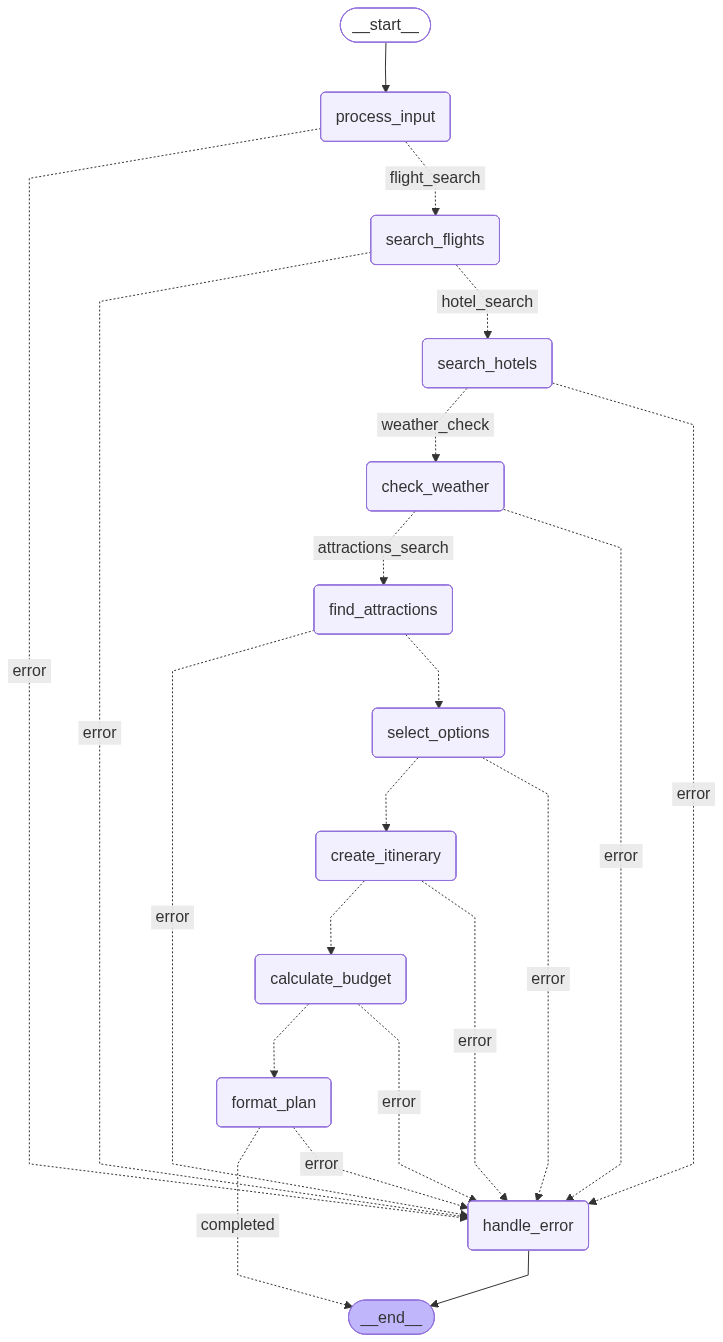


🌍 Planning trip based on: '
I want to plan a romantic trip to Paris for 2 people from August 15-22, 2024. 
Our budget is $3000. We love museums, local cuisine, and historic sites. 
We're departing from New York.
'
🔍 Processing user input...
🤖 Using LLM for intelligent extraction...
✅ Parsed request for Paris for 2 people.
🔄 Routing to stage: flight_search
✈️ Searching for flights...
✅ Found 3 flights within budget.
🔄 Routing to stage: hotel_search
🏨 Searching for hotels...
✅ Found 2 hotels within budget ($146/night).
🔄 Routing to stage: weather_check
🌤️ Checking weather conditions...
✅ Weather forecast: Sunny, 20-25°C.
🔄 Routing to stage: attractions_search
🎭 Finding attractions...
✅ Found 0 attractions matching preferences.
🔄 Routing to stage: select_options
🎯 Selecting best options...
✅ Selected flight: Delta ($580.0)
✅ Selected hotel: Budget Inn Montmartre ($85.0/night)
🔄 Routing to stage: create_itinerary
📅 Creating detailed itinerary...
✅ Created 7-day itinerary.
🔄 Routing to sta

In [20]:
from typing import Dict, List, Any, Optional, Annotated, TypedDict
from datetime import datetime, timedelta
import json
import random
from dataclasses import dataclass, asdict
import re
import os

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from IPython.display import Image, display

# -------------------------
# --- Data Structures ---
# -------------------------

@dataclass
class TravelRequest:
    """User's travel request details"""
    origin: str
    destination: str
    departure_date: str
    return_date: str
    travelers: int
    budget: float
    preferences: List[str]
    trip_type: str  # business, leisure, adventure, family

@dataclass
class FlightOption:
    """Flight search result"""
    airline: str
    departure_time: str
    arrival_time: str
    duration: str
    price: float
    stops: int

@dataclass
class HotelOption:
    """Hotel search result"""
    name: str
    rating: float
    price_per_night: float
    amenities: List[str]
    location: str
    distance_to_center: float

@dataclass
class WeatherInfo:
    """Weather information"""
    temperature_range: str
    conditions: str
    precipitation_chance: int
    recommendations: List[str]

@dataclass
class Attraction:
    """Tourist attraction information"""
    name: str
    category: str
    rating: float
    estimated_time: str
    cost: float
    description: str

@dataclass
class DayPlan:
    """Daily itinerary"""
    day: int
    date: str
    activities: List[Dict[str, Any]]
    estimated_cost: float
    notes: str

# -----------------
# --- Graph State ---
# -----------------

class TravelPlannerState(TypedDict):
    """
    Complete state for the travel planner agent.

    This state flows through all nodes and accumulates information
    throughout the planning process.
    """
    # User input and preferences
    user_request: str                    # Original user input
    travel_request: Optional[TravelRequest]  # Parsed travel details

    # Search results
    flight_options: List[FlightOption]   # Available flights
    hotel_options: List[HotelOption]     # Available hotels
    weather_info: Optional[WeatherInfo]  # Destination weather
    attractions: List[Attraction]        # Local attractions

    # Selected options
    selected_flight: Optional[FlightOption]  # Chosen flight
    selected_hotel: Optional[HotelOption]    # Chosen hotel

    # Planning results
    itinerary: List[DayPlan]            # Day-by-day plan
    total_cost: float                   # Total trip cost
    cost_breakdown: Dict[str, float]    # Detailed costs

    # Process control
    planning_stage: str                 # Current planning phase
    errors: List[str]                   # Any errors encountered
    completed_steps: List[str]          # Completed planning steps

    # Final output
    final_plan: str                     # Formatted travel plan

def create_initial_state(user_request: str) -> TravelPlannerState:
    """Create initial state from user request"""
    return TravelPlannerState(
        user_request=user_request,
        travel_request=None,
        flight_options=[],
        hotel_options=[],
        weather_info=None,
        attractions=[],
        selected_flight=None,
        selected_hotel=None,
        itinerary=[],
        total_cost=0.0,
        cost_breakdown={},
        planning_stage="input_processing",
        errors=[],
        completed_steps=[],
        final_plan=""
    )

# -----------------
# --- Agent Nodes ---
# -----------------

def get_llm():
    """Get OpenAI LLM instance with API key from environment"""
    api_key = os.getenv("OPENAI_API_KEY")
    if not api_key:
        print("⚠️ Warning: OPENAI_API_KEY not found in environment variables")
        print("   Set it using: export OPENAI_API_KEY='your-api-key-here'")
        return None
    return ChatOpenAI(model="gpt-4.1-mini", temperature=0.1)

def extract_with_regex(text: str) -> dict:
    """Fallback regex-based extraction for when LLM is not available"""
    extracted = {}

    month_patterns = [
        r'(January|February|March|April|May|June|July|August|September|October|November|December)\s+(\d{1,2}),?\s+(\d{4})',
        r'(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s+(\d{1,2}),?\s+(\d{4})'
    ]
    numeric_patterns = [
        r'(\d{4}-\d{2}-\d{2})',
        r'(\d{1,2}/\d{1,2}/\d{4})',
        r'(\d{1,2}-\d{1,2}-\d{4})',
    ]

    dates = []
    for pattern in month_patterns:
        matches = re.findall(pattern, text, re.IGNORECASE)
        for match in matches:
            try:
                month_name, day, year = match
                month_map = {
                    'january': '01', 'jan': '01', 'february': '02', 'feb': '02',
                    'march': '03', 'mar': '03', 'april': '04', 'apr': '04',
                    'may': '05', 'june': '06', 'jun': '06', 'july': '07', 'jul': '07',
                    'august': '08', 'aug': '08', 'september': '09', 'sep': '09',
                    'october': '10', 'oct': '10', 'november': '11', 'nov': '11',
                    'december': '12', 'dec': '12'
                }
                month_num = month_map.get(month_name.lower(), '01')
                date_str = f"{year}-{month_num}-{day.zfill(2)}"
                dates.append(date_str)
            except:
                continue
    if not dates:
        dates.extend(re.findall(numeric_patterns[0], text))

    budget_patterns = [r'\$(\d{1,3}(?:,\d{3})*)', r'budget.*?(\d{1,3}(?:,\d{3})*)', r'(\d{1,3}(?:,\d{3})*)\s*dollars?']
    budget = 2000.0
    for pattern in budget_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            budget = float(match.group(1).replace(',', ''))
            break
    extracted['budget'] = budget

    traveler_patterns = [r'(\d+)\s+(?:people|person|traveler|passenger)', r'for\s+(\d+)', r'(\d+)\s+of\s+us']
    travelers = 1
    for pattern in traveler_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            travelers = int(match.group(1))
            break
    extracted['travelers'] = travelers

    cities = re.findall(r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*\b', text)
    if len(cities) >= 2:
        extracted['origin'] = cities[0]
        extracted['destination'] = cities[1]
    elif len(cities) == 1:
        extracted['destination'] = cities[0]
        extracted['origin'] = "New York"
    else:
        extracted['origin'] = "New York"
        extracted['destination'] = "Paris"

    if len(dates) >= 2:
        extracted['departure_date'] = dates[0]
        extracted['return_date'] = dates[1]
    else:
        today = datetime.now()
        extracted['departure_date'] = (today + timedelta(days=30)).strftime("%Y-%m-%d")
        extracted['return_date'] = (today + timedelta(days=37)).strftime("%Y-%m-%d")

    text_lower = text.lower()
    if any(word in text_lower for word in ['business', 'work']): extracted['trip_type'] = 'business'
    elif any(word in text_lower for word in ['family', 'kids']): extracted['trip_type'] = 'family'
    elif any(word in text_lower for word in ['adventure', 'hiking']): extracted['trip_type'] = 'adventure'
    else: extracted['trip_type'] = 'leisure'

    preference_keywords = {'museums': ['museum', 'art'], 'local cuisine': ['food', 'restaurant'], 'history': ['history', 'historical'], 'nature': ['nature', 'park']}
    preferences = [pref for pref, keywords in preference_keywords.items() if any(keyword in text_lower for keyword in keywords)]
    extracted['preferences'] = preferences if preferences else ['local cuisine', 'history', 'museums']

    return extracted

def process_user_input(state: TravelPlannerState) -> TravelPlannerState:
    """Parse user input and extract travel requirements."""
    print("🔍 Processing user input...")
    user_request = state['user_request']

    try:
        llm = get_llm()
        if llm:
            print("🤖 Using LLM for intelligent extraction...")
            system_prompt = """You are a travel planning assistant. Extract travel information from user requests in JSON format: {"origin": "...", "destination": "...", "departure_date": "YYYY-MM-DD", "return_date": "YYYY-MM-DD", "travelers": ..., "budget": ..., "preferences": [...], "trip_type": "..."}. Make reasonable assumptions for missing information (e.g., departure 30 days from now, budget $2000/person)."""
            messages = [SystemMessage(content=system_prompt), HumanMessage(content=f"User request: {user_request}")]
            response = llm.invoke(messages)
            json_match = re.search(r'```json\n(.*?)\n```', response.content, re.DOTALL)
            extracted_data = json.loads(json_match.group(1) if json_match else response.content)
        else:
            print("📝 Using regex-based extraction (fallback)...")
            extracted_data = extract_with_regex(user_request)

        travel_request = TravelRequest(**extracted_data)
        print(f"✅ Parsed request for {travel_request.destination} for {travel_request.travelers} people.")

        updated_state = dict(state)
        updated_state.update({
            'travel_request': travel_request,
            'planning_stage': "flight_search",
            'completed_steps': state['completed_steps'] + ["input_processing"]
        })
        return TravelPlannerState(**updated_state)

    except Exception as e:
        print(f"❌ Error processing input: {e}")
        travel_request = TravelRequest("New York", "Paris", "2024-08-15", "2024-08-22", 2, 3000.0, ["museums", "local cuisine"], "leisure")
        updated_state = dict(state)
        updated_state.update({
            'travel_request': travel_request,
            'planning_stage': "flight_search",
            'completed_steps': state['completed_steps'] + ["input_processing"],
            'errors': state['errors'] + [f"Input processing error (using fallback): {str(e)}"]
        })
        return TravelPlannerState(**updated_state)

def search_flights(state: TravelPlannerState) -> TravelPlannerState:
    """Search for available flights."""
    print("✈️ Searching for flights...")
    travel_req = state['travel_request']
    if not travel_req:
        return TravelPlannerState(**state, errors=state['errors'] + ["No travel request found"])

    mock_flights = [
        FlightOption("Air France", "08:00", "21:30", "7h 30m", 650.0, 0),
        FlightOption("Delta", "14:15", "04:45+1", "8h 30m", 580.0, 1),
        FlightOption("British Airways", "22:00", "11:15+1", "7h 15m", 720.0, 0)
    ]
    budget_per_person = travel_req.budget / travel_req.travelers / 2
    suitable_flights = [f for f in mock_flights if f.price <= budget_per_person]
    print(f"✅ Found {len(suitable_flights)} flights within budget.")

    updated_state = dict(state)
    updated_state.update({
        'flight_options': suitable_flights,
        'planning_stage': "hotel_search",
        'completed_steps': state['completed_steps'] + ["flight_search"]
    })
    return TravelPlannerState(**updated_state)

def search_hotels(state: TravelPlannerState) -> TravelPlannerState:
    """Search for hotels."""
    print("🏨 Searching for hotels...")
    travel_req = state['travel_request']
    if not travel_req:
        return TravelPlannerState(**state, errors=state['errors'] + ["No travel request found"])

    mock_hotels = [
        HotelOption("Hotel du Louvre", 4.5, 180.0, ["WiFi", "Breakfast", "Gym"], "1st Arrondissement", 0.5),
        HotelOption("Boutique Hotel Marais", 4.2, 120.0, ["WiFi", "Bar"], "4th Arrondissement", 1.2),
        HotelOption("Budget Inn Montmartre", 3.8, 85.0, ["WiFi"], "18th Arrondissement", 3.5)
    ]
    departure = datetime.strptime(travel_req.departure_date, "%Y-%m-%d")
    return_date = datetime.strptime(travel_req.return_date, "%Y-%m-%d")
    nights = (return_date - departure).days
    flight_cost = state['flight_options'][0].price * travel_req.travelers if state['flight_options'] else 0
    remaining_budget = travel_req.budget - flight_cost
    budget_per_night = (remaining_budget * 0.6) / nights
    suitable_hotels = [h for h in mock_hotels if h.price_per_night <= budget_per_night]
    print(f"✅ Found {len(suitable_hotels)} hotels within budget (${budget_per_night:.0f}/night).")

    updated_state = dict(state)
    updated_state.update({
        'hotel_options': suitable_hotels,
        'planning_stage': "weather_check",
        'completed_steps': state['completed_steps'] + ["hotel_search"]
    })
    return TravelPlannerState(**updated_state)

def check_weather(state: TravelPlannerState) -> TravelPlannerState:
    """Check weather conditions."""
    print("🌤️ Checking weather conditions...")
    weather_info = WeatherInfo("20-25°C", "Sunny", 10, ["Light clothing", "Sunscreen"])
    print(f"✅ Weather forecast: {weather_info.conditions}, {weather_info.temperature_range}.")

    updated_state = dict(state)
    updated_state.update({
        'weather_info': weather_info,
        'planning_stage': "attractions_search",
        'completed_steps': state['completed_steps'] + ["weather_check"]
    })
    return TravelPlannerState(**updated_state)

def find_attractions(state: TravelPlannerState) -> TravelPlannerState:
    """Find attractions and activities."""
    print("🎭 Finding attractions...")
    travel_req = state['travel_request']
    if not travel_req:
        return TravelPlannerState(**state, errors=state['errors'] + ["No travel request found"])

    all_attractions = [
        Attraction("Louvre Museum", "museum", 4.6, "3-4 hours", 17.0, "World's largest art museum"),
        Attraction("Eiffel Tower", "landmark", 4.5, "2-3 hours", 25.0, "Iconic iron tower"),
        Attraction("Notre-Dame Cathedral", "historic", 4.4, "1-2 hours", 0.0, "Gothic masterpiece"),
        Attraction("Local Cooking Class", "experience", 4.7, "3-4 hours", 85.0, "Learn French cuisine"),
        Attraction("Latin Quarter Food Tour", "food", 4.5, "3 hours", 65.0, "Taste local specialties")
    ]
    preferences = set(travel_req.preferences)
    top_attractions = [a for a in all_attractions if any(p in a.category or p in a.description.lower() for p in preferences)]
    print(f"✅ Found {len(top_attractions)} attractions matching preferences.")

    # Create an updated state dictionary first
    updated_state = dict(state)
    updated_state.update({
        'attractions': top_attractions,
        'planning_stage': "select_options",
        'completed_steps': state['completed_steps'] + ["attractions_search"]
    })

    # Return the new state
    return TravelPlannerState(**updated_state)

    return TravelPlannerState(**state, attractions=top_attractions, planning_stage="select_options", completed_steps=state['completed_steps'] + ["attractions_search"])

def select_best_options(state: TravelPlannerState) -> TravelPlannerState:
    """Select the best flight and hotel."""
    print("🎯 Selecting best options...")
    best_flight = min(state['flight_options'], key=lambda f: f.price + (f.stops * 50)) if state['flight_options'] else None
    best_hotel = min(state['hotel_options'], key=lambda h: h.price_per_night - h.rating * 10) if state['hotel_options'] else None

    if best_flight:
        print(f"✅ Selected flight: {best_flight.airline} (${best_flight.price})")
    if best_hotel:
        print(f"✅ Selected hotel: {best_hotel.name} (${best_hotel.price_per_night}/night)")

    # Create an updated state dictionary first
    updated_state = dict(state)
    updated_state.update({
        'selected_flight': best_flight,
        'selected_hotel': best_hotel,
        'planning_stage': "create_itinerary",
        'completed_steps': state['completed_steps'] + ["select_options"]
    })

    # Return the new state
    return TravelPlannerState(**updated_state)
    return TravelPlannerState(**state, selected_flight=best_flight, selected_hotel=best_hotel, planning_stage="create_itinerary", completed_steps=state['completed_steps'] + ["select_options"])

def create_itinerary(state: TravelPlannerState) -> TravelPlannerState:
    """Create a day-by-day itinerary."""
    print("📅 Creating detailed itinerary...")
    travel_req = state['travel_request']
    if not travel_req:
        # Correctly handle the case where travel_request is missing
        updated_state = dict(state)
        updated_state.update({'errors': state['errors'] + ["No travel request found"]})
        return TravelPlannerState(**updated_state)

    departure = datetime.strptime(travel_req.departure_date, "%Y-%m-%d")
    return_date = datetime.strptime(travel_req.return_date, "%Y-%m-%d")
    days = (return_date - departure).days
    itinerary = []
    attractions = state['attractions']

    attractions_per_day = len(attractions) // days if days > 0 else len(attractions)

    for day in range(days):
        day_attractions = attractions[day * attractions_per_day:(day + 1) * attractions_per_day]
        activities = [{"time": "Morning", "activity": a.name, "description": a.description, "cost": a.cost} for a in day_attractions]
        daily_cost = sum(a['cost'] for a in activities)
        itinerary.append(DayPlan(day + 1, (departure + timedelta(days=day)).strftime("%Y-%m-%d"), activities, daily_cost, "Enjoy the day!"))

    print(f"✅ Created {len(itinerary)}-day itinerary.")

    # Create an updated state dictionary first
    updated_state = dict(state)
    updated_state.update({
        'itinerary': itinerary,
        'planning_stage': "calculate_budget",
        'completed_steps': state['completed_steps'] + ["create_itinerary"]
    })

    # Return the new state
    return TravelPlannerState(**updated_state)
def calculate_budget(state: TravelPlannerState) -> TravelPlannerState:
    """Calculate total trip cost and provide detailed breakdown."""
    print("💰 Calculating budget...")
    cost_breakdown = {}
    total_cost = 0.0

    if state['selected_flight'] and state['travel_request']:
        flight_cost = state['selected_flight'].price * state['travel_request'].travelers * 2  # Round trip
        cost_breakdown['Flights'] = flight_cost
        total_cost += flight_cost

    if state['selected_hotel'] and state['travel_request']:
        nights = (datetime.strptime(state['travel_request'].return_date, "%Y-%m-%d") - datetime.strptime(state['travel_request'].departure_date, "%Y-%m-%d")).days
        hotel_cost = state['selected_hotel'].price_per_night * nights
        cost_breakdown['Accommodation'] = hotel_cost
        total_cost += hotel_cost

    activities_cost = sum(day.estimated_cost for day in state['itinerary'])
    if activities_cost > 0:
        cost_breakdown['Activities & Dining'] = activities_cost
        total_cost += activities_cost

    print(f"✅ Total estimated cost: ${total_cost:.2f}")

    # Create an updated state dictionary first
    updated_state = dict(state)
    updated_state.update({
        'total_cost': total_cost,
        'cost_breakdown': cost_breakdown,
        'planning_stage': "format_plan",
        'completed_steps': state['completed_steps'] + ["calculate_budget"]
    })

    return TravelPlannerState(**updated_state)
def format_final_plan(state: TravelPlannerState) -> TravelPlannerState:
    """Format all information into a comprehensive travel plan."""
    print("📝 Formatting final travel plan...")
    tr = state['travel_request']
    flight = state['selected_flight']
    hotel = state['selected_hotel']

    plan = f"🌍 YOUR PERSONALIZED TRAVEL PLAN TO {tr.destination.upper()} 🌍\n\n"
    plan += f"✈️ Trip Overview:\n   - Dates: {tr.departure_date} to {tr.return_date}\n   - Travelers: {tr.travelers}\n   - Budget: ${tr.budget:.2f}\n\n"
    if flight: plan += f"✈️ Selected Flight:\n   - Airline: {flight.airline}, Price: ${flight.price}\n\n"
    if hotel: plan += f"🏨 Selected Accommodation:\n   - Hotel: {hotel.name}, Rating: {hotel.rating}⭐\n\n"

    plan += "📅 Detailed Itinerary:\n"
    for day in state['itinerary']:
        plan += f"   --- DAY {day.day} ({day.date}) ---\n"
        for act in day.activities:
            plan += f"   • {act['time']}: {act['activity']} (${act['cost']})\n"

    plan += f"\n💰 Budget Breakdown:\n   - Total Cost: ${state['total_cost']:.2f}\n"
    for category, cost in state['cost_breakdown'].items():
        plan += f"   - {category}: ${cost:.2f}\n"

    print("✅ Final travel plan formatted successfully!")

    # Create an updated state dictionary first
    updated_state = dict(state)
    updated_state.update({
        'final_plan': plan,
        'planning_stage': "completed",
        'completed_steps': state['completed_steps'] + ["format_plan"]
    })

    return TravelPlannerState(**updated_state)
def handle_error(state: TravelPlannerState) -> TravelPlannerState:
    """Handle any errors during planning."""
    print("❌ Handling planning errors...")
    error_summary = "\n".join(state['errors'])
    final_plan = f"🚨 TRAVEL PLANNING ERROR 🚨\n\nIssues encountered: {error_summary}\n\nPlease try again."
    return TravelPlannerState(**state, final_plan=final_plan, planning_stage="error_handled")

# ----------------------------
# --- Graph Routing Logic ---
# ----------------------------

# --- THIS IS THE CORRECTED FUNCTION ---
def route_planning_stage(state: TravelPlannerState) -> str:
    """
    Route based on current planning stage.
    This function simply returns the value of 'planning_stage' from the state,
    which is then used as the key in the conditional edge mappings.
    """
    stage = state['planning_stage']
    print(f"🔄 Routing to stage: {stage}")

    if state['errors']:
        return "error"

    return stage

# --------------------
# --- Build Graph ---
# --------------------

print("🏗️ Building the Travel Planner LangGraph...")

travel_planner_graph = StateGraph(TravelPlannerState)

# Add all nodes to the graph
travel_planner_graph.add_node("process_input", process_user_input)
travel_planner_graph.add_node("search_flights", search_flights)
travel_planner_graph.add_node("search_hotels", search_hotels)
travel_planner_graph.add_node("check_weather", check_weather)
travel_planner_graph.add_node("find_attractions", find_attractions)
travel_planner_graph.add_node("select_options", select_best_options)
travel_planner_graph.add_node("create_itinerary", create_itinerary)
travel_planner_graph.add_node("calculate_budget", calculate_budget)
travel_planner_graph.add_node("format_plan", format_final_plan)
travel_planner_graph.add_node("handle_error", handle_error)

# Add entry point
travel_planner_graph.add_edge(START, "process_input")

# Add conditional routing
travel_planner_graph.add_conditional_edges(
    "process_input", route_planning_stage, {
        "flight_search": "search_flights", "error": "handle_error"
    }
)
travel_planner_graph.add_conditional_edges(
    "search_flights", route_planning_stage, {
        "hotel_search": "search_hotels", "error": "handle_error"
    }
)
travel_planner_graph.add_conditional_edges(
    "search_hotels", route_planning_stage, {
        "weather_check": "check_weather", "error": "handle_error"
    }
)
travel_planner_graph.add_conditional_edges(
    "check_weather", route_planning_stage, {
        "attractions_search": "find_attractions", "error": "handle_error"
    }
)
travel_planner_graph.add_conditional_edges(
    "find_attractions", route_planning_stage, {
        "select_options": "select_options", "error": "handle_error"
    }
)
travel_planner_graph.add_conditional_edges(
    "select_options", route_planning_stage, {
        "create_itinerary": "create_itinerary", "error": "handle_error"
    }
)
travel_planner_graph.add_conditional_edges(
    "create_itinerary", route_planning_stage, {
        "calculate_budget": "calculate_budget", "error": "handle_error"
    }
)
travel_planner_graph.add_conditional_edges(
    "calculate_budget", route_planning_stage, {
        "format_plan": "format_plan", "error": "handle_error"
    }
)
travel_planner_graph.add_conditional_edges(
    "format_plan", route_planning_stage, {
        "completed": END, "error": "handle_error"
    }
)
travel_planner_graph.add_edge("handle_error", END)

print("✅ Graph structure complete!")

# --------------------
# --- Compile and Run ---
# --------------------

print("⚙️ Compiling travel planner graph...")
travel_planner = travel_planner_graph.compile()
print("✅ Travel Planner Agent compiled successfully!")

# Visualize the graph
try:
    display(Image(travel_planner.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not visualize graph: {e}")

def plan_trip(user_request: str):
    """Plan a complete trip based on user request."""
    print(f"\n🌍 Planning trip based on: '{user_request}'")
    print("=" * 60)

    initial_state = create_initial_state(user_request)

    try:
        final_state = travel_planner.invoke(initial_state)
        print("\n" + "=" * 60)
        print("🎉 TRAVEL PLANNING COMPLETE!")
        print("=" * 60)
        if final_state.get('final_plan'):
            print(final_state['final_plan'])
        else:
            print("❌ No final plan generated")
        return final_state
    except Exception as e:
        print(f"❌ Error during planning: {e}")
        return None

# --- DEMO ---
sample_request = """
I want to plan a romantic trip to Paris for 2 people from August 15-22, 2024.
Our budget is $3000. We love museums, local cuisine, and historic sites.
We're departing from New York.
"""

result = plan_trip(sample_request)